# User Presence Detection with a Neural Network

This notebook builds a practical deep-learning-style baseline for Wi-Fi CSI user presence detection using the CSV files in `new_data/zones`.

- Label `0`: empty environment / no user present (`activity_00`)
- Label `1`: user present (`activity_01` and any other non-zero activity)

It follows the import pattern already used in the repository and reuses `utils.csv_import_data_analysis` to discover the dataset. The current repo dependencies do not include TensorFlow or PyTorch, so the model here uses `scikit-learn`'s `MLPClassifier`, which is still a multi-layer neural network and fits the current environment cleanly.


In [1]:
from __future__ import annotations

import re
import sys
from pathlib import Path

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from utils.csv_import_data_analysis import get_csv_files_generalistic, sort_meta_info

plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42


In [2]:
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "new_data" / "zones"

# Keep as None to use all scenarios, or pass a subset such as ["22211_A", "22215_ABCDE"].
selected_scenarios: list[str] | None = None

# Windowing and signal-shape controls.
window_size = 32
overlap_size = 16
target_subcarriers = 48
test_size = 0.25

data_files = get_csv_files_generalistic(str(DATA_PATH))
scenarios_id, users_id, activities_id, esps_id, trials_id, zones_id = sort_meta_info(str(DATA_PATH))

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")
print(f"CSV sessions found: {sum(len(trials) for users in data_files.values() for acts in users.values() for esps in acts.values() for trials in esps.values())}")
print(f"Scenarios found ({len(scenarios_id)}): {scenarios_id[:10]}{' ...' if len(scenarios_id) > 10 else ''}")
print(f"Users found: {users_id}")
print(f"Activities found: {activities_id}")


Project root: c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project
Dataset path: c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\new_data\zones
CSV sessions found: 242
Scenarios found (26): ['22211_A', '22211_B', '22211_C', '22211_D', '22211_E', '22212_AB', '22212_AC', '22212_AD', '22212_AE', '22212_BC'] ...
Users found: ['00', '01', '02']
Activities found: ['00', '01']


In [3]:
CSI_PATTERN = re.compile(r"-?\d+")


def normalize_scenario_id(value: str) -> str:
    value_str = str(value).strip()
    if value_str.startswith("scenario_"):
        return value_str

    parts = value_str.split("_", 1)
    if len(parts) == 1 and len(value_str) == 5 and value_str.isdigit():
        return f"scenario_{value_str}"

    if len(parts) == 2 and len(parts[0]) == 5 and parts[0].isdigit():
        return f"scenario_{parts[0]}_{parts[1].upper()}"

    return value_str


def resolve_selected_scenarios(selected: list[str] | None, available_ids: list[str]) -> set[str]:
    if not selected:
        return {normalize_scenario_id(item) for item in available_ids}

    available_set = {normalize_scenario_id(item) for item in available_ids}
    resolved = {normalize_scenario_id(item) for item in selected if normalize_scenario_id(item) in available_set}
    missing = [item for item in selected if normalize_scenario_id(item) not in available_set]
    if missing:
        print(f"[WARN] Ignoring unknown scenarios: {missing}")
    return resolved


def iter_sessions(file_map: dict, selected_ids: set[str]):
    for scenario_key, users_map in file_map.items():
        if scenario_key not in selected_ids:
            continue
        for user_key, activities_map in users_map.items():
            for activity_key, esps_map in activities_map.items():
                for esp_key, trials_map in esps_map.items():
                    for trial_key, file_path in trials_map.items():
                        yield {
                            "scenario": scenario_key,
                            "user": user_key,
                            "activity": activity_key,
                            "esp": esp_key,
                            "trial": trial_key,
                            "file_path": Path(file_path),
                        }


def activity_to_presence_label(activity_key: str) -> int:
    activity_id = str(activity_key).split("_")[-1]
    return 0 if activity_id == "00" else 1


def segment_signal(signal: np.ndarray, window_size: int, overlap: int) -> list[np.ndarray]:
    if overlap >= window_size:
        raise ValueError("Overlap must be smaller than the window size.")

    step = window_size - overlap
    return [signal[i : i + window_size] for i in range(0, signal.shape[0] - window_size + 1, step)]


def resample_vector(values: np.ndarray, target_length: int) -> np.ndarray:
    if values.size == target_length:
        return values.astype(np.float32)

    original_axis = np.linspace(0, 1, num=values.size, dtype=np.float32)
    target_axis = np.linspace(0, 1, num=target_length, dtype=np.float32)
    return np.interp(target_axis, original_axis, values).astype(np.float32)


def extract_packet_magnitude(raw_entry: str, target_length: int) -> np.ndarray | None:
    match = re.search(r"\[(.*?)\]", str(raw_entry))
    if not match:
        return None

    nums = np.array([int(value) for value in CSI_PATTERN.findall(match.group(1))], dtype=np.float32)
    if nums.size < 20 or nums.size % 2 != 0:
        return None

    imag = nums[::2]
    real = nums[1::2]
    magnitude = np.abs(real + 1j * imag)
    return resample_vector(magnitude, target_length)


def load_session_csi(file_path: Path, target_length: int) -> np.ndarray:
    file_csv = pd.read_csv(file_path, header=None)
    csi_column = file_csv.iloc[:, -1]

    packets: list[np.ndarray] = []
    for entry in csi_column:
        packet = extract_packet_magnitude(entry, target_length)
        if packet is not None:
            packets.append(packet)

    if not packets:
        return np.empty((0, target_length), dtype=np.float32)

    csi = np.vstack(packets).astype(np.float32)

    # Per-packet normalization keeps amplitude scales comparable across sessions.
    norms = np.linalg.norm(csi, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return csi / norms


def build_presence_dataset(
    file_map: dict,
    selected_ids: set[str],
    window_size: int,
    overlap_size: int,
    target_length: int,
) -> tuple[np.ndarray, pd.DataFrame]:
    samples: list[np.ndarray] = []
    rows: list[dict[str, object]] = []
    skipped_short = 0
    skipped_empty = 0

    for session in iter_sessions(file_map, selected_ids):
        csi = load_session_csi(session["file_path"], target_length)
        if csi.size == 0:
            skipped_empty += 1
            continue

        windows = segment_signal(csi, window_size=window_size, overlap=overlap_size)
        if not windows:
            skipped_short += 1
            continue

        label = activity_to_presence_label(session["activity"])
        group_id = session["file_path"].stem

        for window_idx, window in enumerate(windows):
            samples.append(window.reshape(-1).astype(np.float32))
            rows.append(
                {
                    "scenario": session["scenario"],
                    "user": session["user"],
                    "activity": session["activity"],
                    "esp": session["esp"],
                    "trial": session["trial"],
                    "group_id": group_id,
                    "file_path": str(session["file_path"]),
                    "window_idx": window_idx,
                    "label": label,
                }
            )

    if not samples:
        raise ValueError("No training windows were generated. Check the selected scenarios and window settings.")

    metadata = pd.DataFrame(rows)
    X = np.vstack(samples)

    print(f"Generated windows: {len(metadata)}")
    print(f"Unique sessions used: {metadata['group_id'].nunique()}")
    print(f"Skipped empty sessions: {skipped_empty}")
    print(f"Skipped short sessions: {skipped_short}")

    return X, metadata


def split_by_group(metadata: pd.DataFrame, test_size: float, random_state: int = 42) -> tuple[np.ndarray, np.ndarray]:
    group_labels = metadata[["group_id", "label"]].drop_duplicates().reset_index(drop=True)

    train_groups, test_groups = train_test_split(
        group_labels["group_id"],
        test_size=test_size,
        random_state=random_state,
        stratify=group_labels["label"],
    )

    train_idx = metadata.index[metadata["group_id"].isin(train_groups)].to_numpy()
    test_idx = metadata.index[metadata["group_id"].isin(test_groups)].to_numpy()
    return train_idx, test_idx


Selected scenarios (26): ['scenario_22211_A', 'scenario_22211_B', 'scenario_22211_C', 'scenario_22211_D', 'scenario_22211_E', 'scenario_22212_AB', 'scenario_22212_AC', 'scenario_22212_AD', 'scenario_22212_AE', 'scenario_22212_BC', 'scenario_22212_BD', 'scenario_22212_BE', 'scenario_22212_CD', 'scenario_22212_CE', 'scenario_22212_DE', 'scenario_22213_ABC', 'scenario_22213_ABD', 'scenario_22213_ABE', 'scenario_22213_ACD', 'scenario_22213_ACE', 'scenario_22213_ADE', 'scenario_22213_BCD', 'scenario_22213_BCE', 'scenario_22213_BDE', 'scenario_22213_CDE', 'scenario_22215_ABCDE']
Generated windows: 50333
Unique sessions used: 242
Skipped empty sessions: 0
Skipped short sessions: 0
Feature matrix shape: (50333, 1536)
Class distribution:
label
empty      24578
present    25755
Name: count, dtype: int64
Session distribution by label:
label
empty      116
present    126
Name: count, dtype: int64


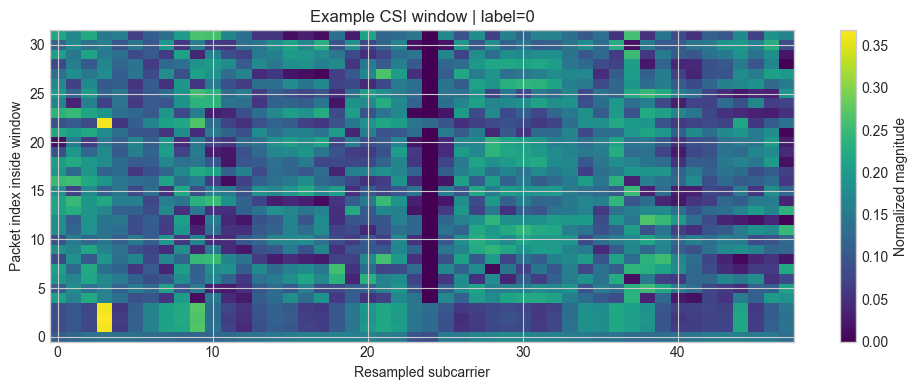

,scenario,user,activity,esp,trial,group_id,file_path,window_idx,label
0,scenario_22211_A,user_00,activity_00,esp_05,trial_01,22211_A_00_00_05_01_2026-03-18_14-13-59,c:\Users\pedro\OneDrive - Universidade de Coim...,0,0
1,scenario_22211_A,user_00,activity_00,esp_05,trial_01,22211_A_00_00_05_01_2026-03-18_14-13-59,c:\Users\pedro\OneDrive - Universidade de Coim...,1,0
2,scenario_22211_A,user_00,activity_00,esp_05,trial_01,22211_A_00_00_05_01_2026-03-18_14-13-59,c:\Users\pedro\OneDrive - Universidade de Coim...,2,0
3,scenario_22211_A,user_00,activity_00,esp_05,trial_01,22211_A_00_00_05_01_2026-03-18_14-13-59,c:\Users\pedro\OneDrive - Universidade de Coim...,3,0
4,scenario_22211_A,user_00,activity_00,esp_05,trial_01,22211_A_00_00_05_01_2026-03-18_14-13-59,c:\Users\pedro\OneDrive - Universidade de Coim...,4,0


In [4]:
selected_ids = resolve_selected_scenarios(selected_scenarios, scenarios_id)
print(f"Selected scenarios ({len(selected_ids)}): {sorted(selected_ids)}")

X, metadata = build_presence_dataset(
    file_map=data_files,
    selected_ids=selected_ids,
    window_size=window_size,
    overlap_size=overlap_size,
    target_length=target_subcarriers,
)

print(f"Feature matrix shape: {X.shape}")
print("Class distribution:")
print(metadata["label"].value_counts().sort_index().rename(index={0: "empty", 1: "present"}))
print("Session distribution by label:")
print(metadata[["group_id", "label"]].drop_duplicates()["label"].value_counts().sort_index().rename(index={0: "empty", 1: "present"}))

sample_idx = 0
plt.figure(figsize=(10, 4))
plt.imshow(X[sample_idx].reshape(window_size, target_subcarriers), aspect="auto", origin="lower", cmap="viridis")
plt.colorbar(label="Normalized magnitude")
plt.title(f"Example CSI window | label={metadata.iloc[sample_idx]['label']}")
plt.xlabel("Resampled subcarrier")
plt.ylabel("Packet index inside window")
plt.tight_layout()
plt.show()

metadata.head()


In [5]:
train_idx, test_idx = split_by_group(metadata, test_size=test_size, random_state=RANDOM_STATE)

X_train = X[train_idx]
X_test = X[test_idx]
y_train = metadata.loc[train_idx, "label"].to_numpy()
y_test = metadata.loc[test_idx, "label"].to_numpy()

print(f"Train windows: {len(train_idx)} | Test windows: {len(test_idx)}")
print(f"Train sessions: {metadata.loc[train_idx, 'group_id'].nunique()} | Test sessions: {metadata.loc[test_idx, 'group_id'].nunique()}")

presence_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=(256, 128, 64),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                batch_size=32,
                learning_rate_init=1e-3,
                max_iter=200,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=20,
                random_state=RANDOM_STATE,
                verbose=False,
            ),
        ),
    ]
)

presence_model.fit(X_train, y_train)
presence_model


Train windows: 37656 | Test windows: 12677
Train sessions: 181 | Test sessions: 61


Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(batch_size=32, early_stopping=True,
                               hidden_layer_sizes=(256, 128, 64),
                               n_iter_no_change=20, random_state=42,
                               validation_fraction=0.15))])

Window-level metrics:
accuracy     0.6396
precision    0.6344
recall       0.7121
f1           0.6710
roc_auc      0.6345
dtype: float64

Classification report:

              precision    recall  f1-score   support

       empty       0.65      0.56      0.60      6134
     present       0.63      0.71      0.67      6543

    accuracy                           0.64     12677
   macro avg       0.64      0.64      0.64     12677
weighted avg       0.64      0.64      0.64     12677



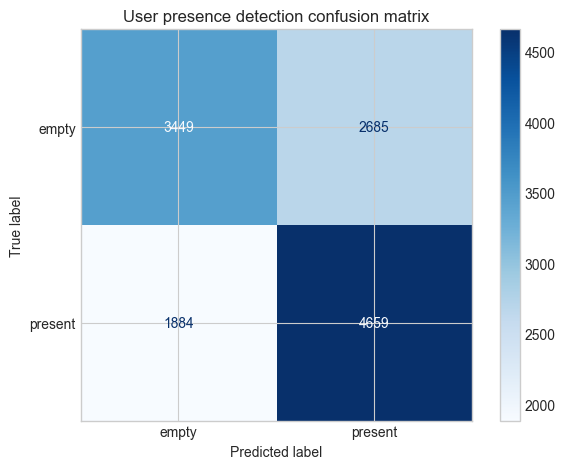

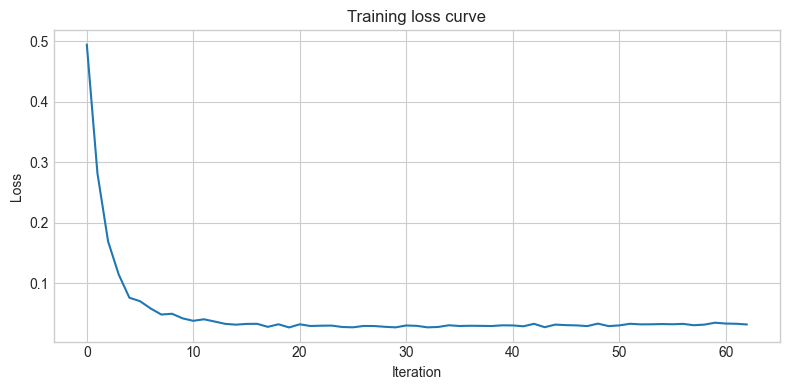

In [6]:
y_pred = presence_model.predict(X_test)
y_score = presence_model.predict_proba(X_test)[:, 1]

metrics_summary = pd.Series(
    {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
    }
).round(4)

print("Window-level metrics:")
print(metrics_summary)
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=["empty", "present"], zero_division=0))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["empty", "present"]).plot(cmap="Blues")
plt.title("User presence detection confusion matrix")
plt.tight_layout()
plt.show()

mlp_step = presence_model.named_steps["mlp"]
plt.figure(figsize=(8, 4))
plt.plot(mlp_step.loss_curve_)
plt.title("Training loss curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()


In [7]:
test_results = metadata.loc[test_idx, ["group_id", "scenario", "user", "activity", "esp", "trial", "file_path", "label"]].copy()
test_results["pred_label"] = y_pred
test_results["pred_score"] = y_score

session_summary = (
    test_results.groupby("group_id")
    .agg(
        scenario=("scenario", "first"),
        user=("user", "first"),
        activity=("activity", "first"),
        esp=("esp", "first"),
        trial=("trial", "first"),
        file_path=("file_path", "first"),
        true_label=("label", "first"),
        predicted_probability=("pred_score", "mean"),
    )
    .reset_index()
)
session_summary["predicted_label"] = (session_summary["predicted_probability"] >= 0.5).astype(int)
session_summary["correct"] = session_summary["predicted_label"] == session_summary["true_label"]

print("Session-level metrics:")
print(
    pd.Series(
        {
            "accuracy": accuracy_score(session_summary["true_label"], session_summary["predicted_label"]),
            "f1": f1_score(session_summary["true_label"], session_summary["predicted_label"], zero_division=0),
        }
    ).round(4)
)

session_summary.sort_values(["correct", "predicted_probability"], ascending=[True, False]).head(10)


Session-level metrics:
accuracy    0.7541
f1          0.7887
dtype: float64


,group_id,scenario,user,activity,esp,trial,file_path,true_label,predicted_probability,predicted_label,correct
8,22212_AD_00_00_06_02_2026-03-19_15-25-39,scenario_22212_AD,user_00,activity_00,esp_06,trial_02,c:\Users\pedro\OneDrive - Universidade de Coim...,0,0.999997,1,False
25,22213_ABC_00_00_07_02_2026-03-24_15-57-49,scenario_22213_ABC,user_00,activity_00,esp_07,trial_02,c:\Users\pedro\OneDrive - Universidade de Coim...,0,0.997880,1,False
24,22213_ABC_00_00_07_01_2026-03-24_15-42-13,scenario_22213_ABC,user_00,activity_00,esp_07,trial_01,c:\Users\pedro\OneDrive - Universidade de Coim...,0,0.996382,1,False
55,22215_ABCDE_00_00_06_01_2026-04-09_10-42-07,scenario_22215_ABCDE,user_00,activity_00,esp_06,trial_01,c:\Users\pedro\OneDrive - Universidade de Coim...,0,0.996319,1,False
13,22212_BD_00_00_06_01_2026-03-24_10-42-36,scenario_22212_BD,user_00,activity_00,esp_06,trial_01,c:\Users\pedro\OneDrive - Universidade de Coim...,0,0.993502,1,False
27,22213_ABD_00_00_08_02_2026-03-24_16-57-51,scenario_22213_ABD,user_00,activity_00,esp_08,trial_02,c:\Users\pedro\OneDrive - Universidade de Coim...,0,0.989361,1,False
56,22215_ABCDE_00_00_09_02_2026-04-09_10-55-40,scenario_22215_ABCDE,user_00,activity_00,esp_09,trial_02,c:\Users\pedro\OneDrive - Universidade de Coim...,0,0.977471,1,False
54,22215_ABCDE_00_00_05_02_2026-04-09_10-55-40,scenario_22215_ABCDE,user_00,activity_00,esp_05,trial_02,c:\Users\pedro\OneDrive - Universidade de Coim...,0,0.881049,1,False
53,22215_ABCDE_00_00_05_01_2026-04-09_10-42-07,scenario_22215_ABCDE,user_00,activity_00,esp_05,trial_01,c:\Users\pedro\OneDrive - Universidade de Coim...,0,0.862789,1,False
26,22213_ABD_00_00_08_01_2026-03-24_16-17-56,scenario_22213_ABD,user_00,activity_00,esp_08,trial_01,c:\Users\pedro\OneDrive - Universidade de Coim...,0,0.790793,1,False


In [8]:
def predict_presence_for_file(
    file_path: str | Path,
    model: Pipeline,
    window_size: int,
    overlap_size: int,
    target_length: int,
) -> dict[str, object]:
    file_path = Path(file_path)
    csi = load_session_csi(file_path, target_length=target_length)
    windows = segment_signal(csi, window_size=window_size, overlap=overlap_size)

    if not windows:
        raise ValueError(f"File {file_path.name} is too short for the current window size.")

    X_file = np.vstack([window.reshape(-1) for window in windows]).astype(np.float32)
    scores = model.predict_proba(X_file)[:, 1]
    mean_score = float(scores.mean())
    return {
        "file_path": str(file_path),
        "n_windows": int(len(scores)),
        "presence_probability": mean_score,
        "predicted_label": int(mean_score >= 0.5),
    }


# Example inference on one held-out session.
demo_file = Path(session_summary.iloc[0]["file_path"])
predict_presence_for_file(
    file_path=demo_file,
    model=presence_model,
    window_size=window_size,
    overlap_size=overlap_size,
    target_length=target_subcarriers,
)


{'file_path': 'c:\\Users\\pedro\\OneDrive - Universidade de Coimbra\\Ambiente de Trabalho\\tese\\thesis-project\\new_data\\zones\\22211_A_00_00_05_02_2026-03-18_14-26-38.csv',
 'n_windows': 190,
 'presence_probability': 0.5317838191986084,
 'predicted_label': 1}

## Notes

- The pipeline uses a group-aware split, so windows from the same CSV session are not mixed between train and test.
- The CSI parser is intentionally defensive: packet lengths vary across files, so each packet is converted to magnitude and resampled to a fixed number of subcarriers before windowing.
- If you later install TensorFlow or PyTorch, the same windowed dataset can be reused for a 1D CNN or LSTM with minimal changes.
